## MLS SS25 Exercise 3: Find Suspicious Users (31P)
*Adapted from an exercise created by Dennis Eisermann*

Unsupervised learning techniques identify hidden patterns in unlabeled data. In contrast to supervised approaches, they do not rely on predetermined target variables (i.e., classes). This approach can cluster users by their behavior and thus detect potentially suspicious behavior.
You use the [User-Computer Authentication Associations in Time](https://csr.lanl.gov/data/auth/) dataset, which contains 708,304,516 successful authentication events over nine months. 11,362 unique users (Us) perform authenticationss at 22,284 unique computers (Cs). Timestamps are seconds-based offsets from an anonymized epoch. Get the first [30-day file](https://bwsyncandshare.kit.edu/s/4NCeo5KEDYnBTcj) `lanl-auth-dataset-1-00.bz2` (*or* after registering on the website of the authors above) to start experimenting.

### Setup

Install the necessary libraries to perform the following tasks.

In [3]:
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
!pip install kneed

### Task 1 – Exploration of the Dataset (11P)

To get familiar with the dataset and build an initial understanding, try to find correlations and biases in the measured data.

1. Load the csv from `lanl-auth-dataset-1-00.bz2` in a dataframe. Convert the `Time` field to [datetime](https://pandas.pydata.org/docs/getting_started/intro_tutorials/09_timeseries.html) and print the result. (2P)

In [18]:
import pandas as pd

# Read Dataset
column_names = [ 'timestamp', 'user', 'compuer' ]
df_UCAAT = pd.read_csv(
    '../data/lanl-auth-dataset-1-00.bz2',
    compression='bz2',
    header=None,
    names=column_names,
)

df_UCAAT['timestamp'] = pd.to_datetime(df_UCAAT['timestamp'], unit='s')

print(df_UCAAT)

                   timestamp  user compuer
0        1970-01-01 00:00:01    U1      C1
1        1970-01-01 00:00:01    U1      C2
2        1970-01-01 00:00:02    U2      C3
3        1970-01-01 00:00:03    U3      C4
4        1970-01-01 00:00:06    U4      C5
...                      ...   ...     ...
67054835 1970-01-29 00:00:00  U189   C1450
67054836 1970-01-29 00:00:00  U104    C126
67054837 1970-01-29 00:00:00  U104    C127
67054838 1970-01-29 00:00:00   U12    C210
67054839 1970-01-29 00:00:00  U112     C82

[67054840 rows x 3 columns]


2. Show the minimal and maximal time in the dataset. (1P)

In [20]:
print("Min time:", df_UCAAT['timestamp'].min())
print("Max time:", df_UCAAT['timestamp'].max())

Min time: 1970-01-01 00:00:01
Max time: 1970-01-29 00:00:00


3. pandas provides a lot of useful built-in exporation methods. "Describe" how often users create events, i.e., calculate basic statistics like count, mean, and quantiles. (1P)

4. Find out which are the five most frequent users. (1P)

5. Calculate the number of logins separately for each computer. Print on how many different computers the user U12 logged into? (2P)

U12 logged into 164 distinct computers.



6. Think about typical user login patterns you could imagine. Find one argument in support and one against whether U12 is a suspicious user. (2P)

*your answer*

7. Get the maximum number of times U12 has logged in [within](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) one minute. Use a pandas built-in method to solve this. (1P)

8. Calculate how often U12 has logged into different computers within one minute by grouping the dataframe before checking each timeframe. (1P)

SrcUser    47.0
dtype: float64


### Task 2 – Feature Engineering (6P)

In this task you create a dataset with new features to support the model in analysing the user behavior. You try to differentiate between normal users and suspicious ones with unusual behavior.


1. Build a new empty dataset. You will use it to store the relevant features to describe each user. (1P)

2. Add the number of login events for each user to the dataset. Name the column `login_numbers`. (1P)

3. Add the number of different computers for each user. Name the column `computer_numbers`. (1P)

4. Add max logins within a minute for each user. Name the column `max_logins_in_1min`. This will help you find suspicious users with frequent logins in a short amount of time. (1P)

In [ ]:
from pandas import concat


5. Add to the dataset how many times each user has a login event outside the usual business hours between 6:00h and 18:00h. Filter out the weekend. Remember to check for undefined values and handle them. Call the column `out_of_business_times`. We assume that the dataset starts on midnight. (2P)

In [25]:
from datetime import time


         login_numbers  computer_numbers  max_logins_in_1min  \
SrcUser                                                        
U1               83793                39                84.0   
U10              44533                18               112.0   
U100             15322                15                32.0   
U1000            95553                23                94.0   
U1001             2423                 7                26.0   

         out_of_business_times  
SrcUser                         
U1                     29083.0  
U10                     6899.0  
U100                    3961.0  
U1000                  34091.0  
U1001                    305.0  


### Task 3 – Model Training and Evaluation (14P)

In this task you are using a model to cluster the data. This should allow you to identify potentially suspicious users.

1. Define a pipeline which [standard scales](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) its inputs and use [KMeans++](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) afterwards. Use six clusters and 42 as random state. (1P)

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=6, random_state=42))])

2. Cluster the users based on `out_of_business_times` and `max_logins_in_1m`. Visualize the user values and the centroids as [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html). (3P)

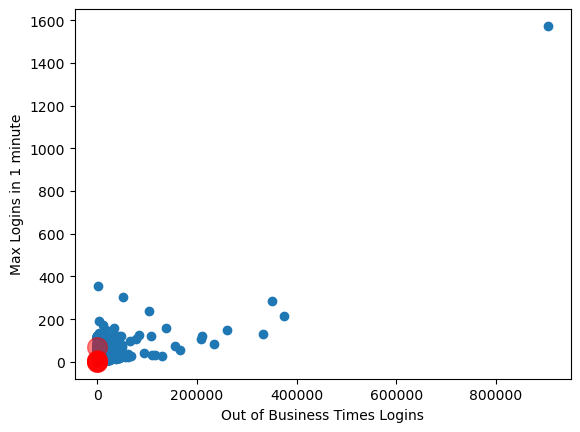

In [27]:
import numpy as np
from matplotlib import pyplot as plt


3. Calculate the kMeans++ error (with all features) for 1 to 10 clusters. Use the [elbow method](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/) to determine the optimal number of clusters. Plot your results. You can use the [kneedle libary](https://pypi.org/project/kneed/). (3P)

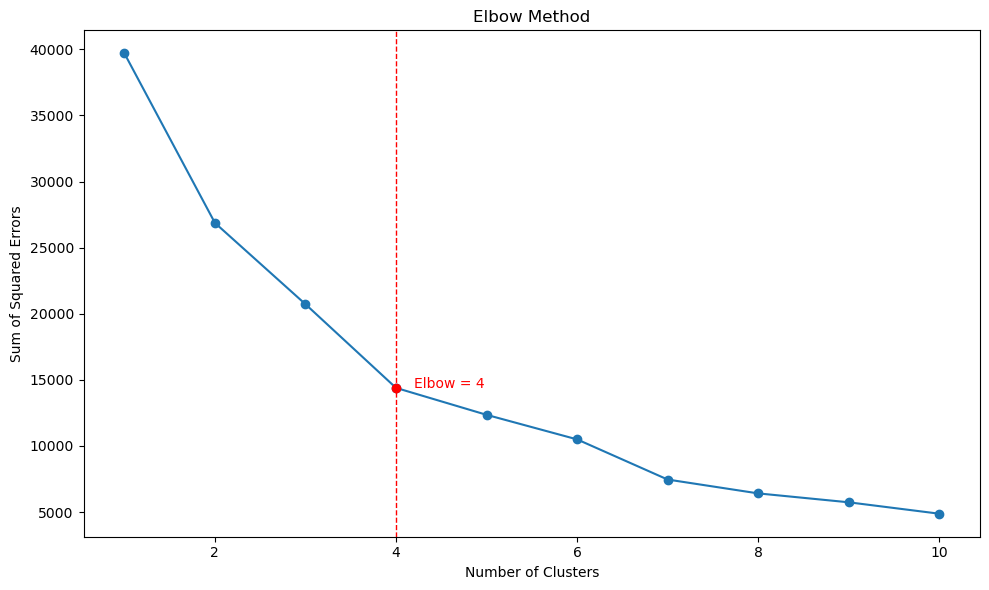

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator


4. Use KMeans++ with the optimal numbers of clusters you determined above. Calculate the outliers based on the centroids. Outliers are datapoints with a higher standard deviation than the average data. Print the outliers as table and the percentage of outliers in comparison to the dataset. (3P)

In [ ]:

print(outliers)
print(f"Outliers: {percentage_outliers}%")

5. Print the strongest outlier. (1P)

6. Provide one argument in favor and one against the conclusion that the determined outlier is a malicious user. (2P)

*your answer*

7. Consider a realistic business scenario and provide one strategy, how to confirm an outlier as malicious actor? (1P)

*your answer*